# Notebook to cross match SGA and fastspecfit to get all shredded galaxies

## imports

In [48]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.io import fits

from astropy.coordinates import SkyCoord
import astropy.units as u

from scipy.spatial import KDTree 
from tqdm import tqdm

from astropy.visualization.wcsaxes import SphericalCircle


from get_cutouts import *

import os

## load data

In [2]:
data_directory = '/global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/'

In [3]:
sga = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', hdu='ELLIPSE')
sga[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

## start with sv3 bright 

In [4]:
sv3_bright = Table.read(data_directory + 'fastspec-loa-sv3-bright.fits', hdu=1)

In [5]:
sv3_bright[:5]

TARGETID,SURVEY,PROGRAM,HEALPIX,TILEID_LIST,RA,DEC,COADD_FIBERSTATUS,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV1_SCND_TARGET,SV2_SCND_TARGET,SV3_SCND_TARGET,Z,ZWARN,DELTACHI2,SPECTYPE,SUBTYPE,Z_RR,ZWARN_RR,TSNR2_BGS,TSNR2_LRG,TSNR2_ELG,TSNR2_QSO,TSNR2_LYA,PHOTSYS,LS_ID,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,EBV,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4
int64,bytes3,bytes6,int32,bytes35,float64,float64,int32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,int64,float64,bytes6,bytes20,float64,int64,float32,float32,float32,float32,float32,bytes1,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float32,float32,float32,float32,float32,float32,float32
39633166985596095,sv3,bright,10016,363,246.10865893366793,45.0907368173874,0,0,0,0,0,0,0,0,0,0,0,0,1152921504606846976,514,0,0,0,0,0.20040203493510256,0,108.03127444535494,GALAXY,--,0.20040203493510256,0,1232.543,12.869423,20.750921,4.90706,8.545107,N,9907736307174591,2.5836415,7.104721,13.163747,2.6525464,7.23072,13.291874,6.600966,17.993935,33.077354,26.67905,18.141243,14.276368,-376.33533,104.28538,60.784584,29.792084,2.3148715,0.8971721,0.005192118,6.519413e-05,0.00877127667307732,0.97402316,0.98257446,0.99036044,0.99851465,0.9990875,0.99980533,0.9999265
39633166985595463,sv3,bright,10016,363,246.05836546875628,45.04464464528466,0,0,0,0,0,0,0,0,0,0,0,0,1152921504606855433,257,0,0,0,0,0.587112499385616,0,43.808030761778355,GALAXY,--,0.587112499385616,0,1263.0671,13.298988,21.638,5.0879087,8.587896,N,9907736307173959,0.83116865,2.666884,7.3044014,0.8538935,2.715365,7.377272,2.5141802,7.9950438,21.72143,71.659744,40.576416,193.11215,1978.4192,165.98729,79.34776,37.028507,2.8699937,1.1946384,0.005508529,6.6347435e-05,0.008989075689792448,0.97338676,0.98214567,0.9901223,0.99847776,0.99906486,0.9998005,0.99992466
39633166985595831,sv3,bright,10016,363,246.08870862641152,45.113868221329604,0,0,0,0,0,0,0,0,0,0,0,0,5764607523034234880,514,0,0,0,79164837199872,0.11460968453893314,0,1533.075475600548,GALAXY,--,0.11460968453893314,0,1170.5703,12.326408,20.103195,4.710272,7.542334,N,9907736307174327,14.222594,36.207348,68.01829,14.580237,36.81294,68.64281,52.089085,131.51723,245.23203,193.1143,122.43054,64.530685,132.56476,24.236807,13.749555,11.051453,1.0788647,0.5325098,0.004118952,5.705979e-05,0.008276367754832224,0.9754707,0.98354954,0.9909019,0.9985984,0.999139,0.9998163,0.9999306
39633166985595580,sv3,bright,10016,363 364,246.06806967667453,45.06877356658734,0,0,0,0,0,0,0,0,0,0,0,0,1152921504606846976,514,0,0,0,0,0.26460987353361964,0,731.124451816082,GALAXY,--,0.26460987353361964,0,1252.0044,13.025433,20.968033,5.057235,8.675689,N,9907736307174076,2.532607,6.6889243,13.424788,2.6020257,6.8108277,13.559053,7.707139,20.173512,40.1616,65.27547,60.83731,339.12576,670.7085,181.56209,82.39993,33.681454,3.0613728,1.058136,0.0054915952,6.849082e-05,0.009011488192600276,0.9733213,0.98210156,0.99009776,0.998474,0.99906254,0.99979997,0.9999245
39633166985595026,sv3,bright,10016,363,246.02158305626224,45.101922649253495,16777216,0,0,0,0,0,0,0,0,0,0,0,1152921504606846976,514,0,0,0,0,0.2467793347236691,2,28.67941853031516,GALAXY,--,0.2467793347236691,2,319.03174,3.6016245,2.3857903,1.0092878,6.1803284,N,9907736307173522,1.4995949,5.5523934,12.814177,1.5372937,5.6452355,12.9318,4.686206,17.208643,39.420628,55.614067,38.060596,51.71272,-268.64413,121.281784,54.203613,21.760153,2.8853838,1.0858693,0.005

In [6]:
coords = np.array([sv3_bright['RA'], sv3_bright['DEC']]).transpose()

In [7]:
tree = KDTree(coords)

In [8]:
sv3_bright['SGA_ID'] = np.ones(len(sv3_bright), dtype='int') * -99

In [9]:
for i in tqdm(range(len(sga))):
    
    indices = tree.query_ball_point((sga['RA'][i], sga['DEC'][i]), sga['D26'][i]/120 + 1/3600)
    if len(indices) > 0:
        sv3_bright['SGA_ID'][indices] = sga['SGA_ID'][i]
    

100%|██████████| 383620/383620 [00:04<00:00, 90632.51it/s]


In [10]:
sv3_bright[sv3_bright['SGA_ID'] > 0]

TARGETID,SURVEY,PROGRAM,HEALPIX,TILEID_LIST,RA,DEC,COADD_FIBERSTATUS,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV1_SCND_TARGET,SV2_SCND_TARGET,SV3_SCND_TARGET,Z,ZWARN,DELTACHI2,SPECTYPE,SUBTYPE,Z_RR,ZWARN_RR,TSNR2_BGS,TSNR2_LRG,TSNR2_ELG,TSNR2_QSO,TSNR2_LYA,PHOTSYS,LS_ID,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,EBV,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,SGA_ID
int64,bytes3,bytes6,int32,bytes35,float64,float64,int32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,int64,float64,bytes6,bytes20,float64,int64,float32,float32,float32,float32,float32,bytes1,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float32,float32,float32,float32,float32,float32,float32,int64
39633297625580551,sv3,bright,10146,311,242.44681511764617,53.32129316913584,0,0,0,0,0,0,0,0,0,0,0,0,5764607523034234880,514,0,0,0,158329674399744,0.036139513269782236,0,37832.12766510248,GALAXY,--,0.036139513269782236,0,1470.576,16.64824,23.762554,5.8673396,17.461214,N,9907738348422151,33.848534,65.958626,106.57572,34.927174,67.35514,107.81322,218.60928,421.57593,674.80316,529.61053,317.5226,955.0673,2761.6672,23.10117,6.0839853,4.913508,0.6953453,0.41898772,0.006087585,8.363071e-05,0.010453960524705947,0.9691174,0.97926646,0.9885219,0.9982299,0.9989126,0.99976796,0.9999124,485990
39633297625580047,sv3,bright,10146,313,242.40130104865122,53.29767924050718,0,0,0,0,0,0,0,0,0,0,0,0,5764607523034234880,514,0,0,0,79164837199872,0.06574158706126836,0,5303.000041991472,GALAXY,--,0.06574158706126836,0,1270.5138,14.119883,20.03891,4.902522,14.076606,N,9907738348421647,30.625147,62.16276,107.46736,31.645935,63.539085,108.77199,248.08893,498.1159,852.7201,821.26587,540.71606,2962.0627,4618.5195,16.672115,3.9871056,3.7459428,0.4437945,0.24871601,0.0042497288,6.748174e-05,0.010926768915560953,0.96774346,0.97833896,0.9880059,0.99814993,0.9988634,0.99975747,0.99990845,456117
39633297625580886,sv3,bright,10146,317,242.47817794335853,53.34656757347522,0,0,0,0,0,0,0,0,0,0,0,0,5764607523034234880,514,0,0,0,79164837199872,0.06445617437268052,0,3158.8037129342556,GALAXY,--,0.06445617437268052,0,1586.8531,17.46867,27.024393,6.376308,12.789555,N,9907738348422486,13.126531,31.15959,61.518448,13.51942,31.779436,62.189774,105.30919,247.54512,484.42566,458.2296,289.85992,555.75336,523.7249,29.196468,6.1942525,3.7091568,0.6625939,0.36135414,0.0043622665,6.805069e-05,0.009828190493160381,0.9709389,0.98049533,0.98920524,0.9983358,0.99897766,0.99978185,0.9999176,1186207
39633301245264511,sv3,bright,10147,309,242.85956302890338,53.5681034704526,0,0,0,0,0,0,0,0,0,0,0,0,5764607523034234880,514,0,0,0,79164837199872,0.06594368890306722,0,4174.047140486306,GALAXY,--,0.06594368890306722,0,1607.863,17.717016,24.703861,6.2178855,12.211271,N,9907738404979327,26.369637,62.417194,113.60121,27.25006,63.80146,114.9826,155.55464,364.2052,656.36835,513.01025,297.96985,145.46666,80.35821,23.026066,7.392133,4.444617,0.61821264,0.3729533,0.004853879,7.134042e-05,0.01094482909840283,0.967691,0.97830355,0.98798615,0.9981469,0.99886155,0.9997571,0.99990827,1178697
39633301249461774,sv3,bright,10147,309 311,243.59360868066247,53.59806674064587,0,0,0,0,0,0,0,0,0,0,0,0,5764607523034234880,514,0,0,0,158329674399744,0.04803028555940999,0,4344.158941649832,GALAXY,--,0.04803028555940999,0,1330.0823,14.410518,22.781364,5.6890297,23.126425,N,9907738405047822,10.131823,20.377954,32.910744,10.396879,20.732481,33.225014,569.28156,1135.

## check that this was successful

load a cutout for one galaxy and plot these fibers

In [26]:
ids, counts = np.unique(sv3_bright[sv3_bright['SGA_ID'] > 0]['SGA_ID'], return_counts=1)

In [27]:
ids[np.argmax(counts)]

np.int64(608015)

In [28]:
targ = sga[sga['SGA_ID']== 608015]
targ

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
608015,SGA-2020 608015,NGC5364,49555,209.04988949999998,5.0146562,Sbc,30.0,6.76083,0.65,0.004135194,23.96948,11.191,True,LEDA-20181114,222274,NGC5364,1,True,209.04988949999998,5.0146562,6.76083,2089p050,209.05006258871558,5.014919816840345,8.511011,SB26,37.585308,0.6445725,209.04998952592558,5.014992601766482,193.64487,91.29532,88.1987,86.08719,67.68143,90.257164,115.06518,142.8107,170.79346,197.82199,221.3718,240.17175,255.33034,11.958419,11.254497,10.694683,11.67637,10.982817,10.430503,11.447776,10.77013,10.227698,11.281962,10.615305,10.081666,11.169618,10.512704,9.986065,11.0927925,10.442088,9.919294,11.044476,10.395658,9.874932,11.019668,10.371094,9.850604,11.005895,10.358129,9.837773,0.09855458,0.11773693,0.17762117,0.1872824,0.19020398,0.3272438,0.40794593,0.4933505,0.43684292,0.00080263714,0.0008679493,0.0008945351,0.00066927786,0.00071627385,0.00073870615,0.00058426877,0.0006236456,0.00064593955,0.0005357778,0.00056822464,0.000590164,0.0005006247,0.0005294005,0.00055133866,0.00047752613,0.00050490734,0.00052694086,0.00046604162,0.0004916377,0.0005137854,0.00046026066,0.00048514243,0.0005074434,0.00045703514,0.0004818224,0.0005043025,10.909382,0.34202942,8334.74,3.1405003,172.66557,10.248852,0.39043656,2344.68,2.7513144,120.84411,9.717289,0.4478612,862.74615,2.4553945,102.02348,0


In [29]:
sgaid = targ['SGA_ID'][0]
ra, dec = float(targ['RA'][0]), float(targ['DEC'][0])


# D26 in arcmin
d26 = targ['D26'][0]

dr = 10

pix = int(2 * d26*60/0.262)

if (pix < 2500):
    npix = np.minimum(pix,1024)

elif (pix > 2500):
    npix = np.minimum(pix,3000)

img_file, wcs = get_cutout(sgaid, ra, dec, dr=dr, dir='/pscratch/sd/n/nravi/legacysurvey_cache/',size=npix)

In [30]:
targ_list = sv3_bright[sv3_bright['SGA_ID'] == sgaid]

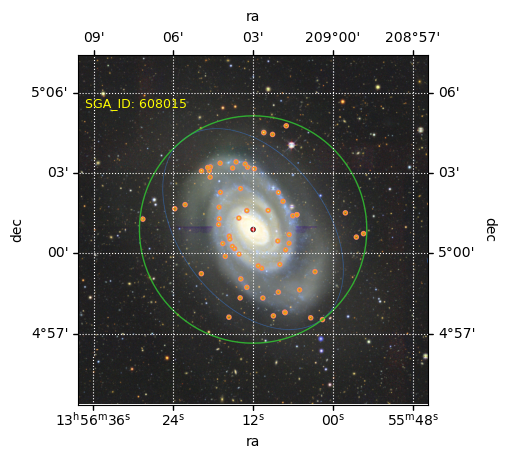

In [45]:
img = mpl.image.imread(img_file)

fig1 = plt.figure(figsize=(7,5))

ax = fig1.add_subplot(111, projection=wcs)
ax.imshow(np.flip(img, axis=0))
ax.set(xlabel='ra', ylabel='dec')
ax.text(int(0.02*npix), int(0.85*npix), 'SGA_ID: {}'.format(sgaid), fontsize=9, color='yellow')
overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='white', ls='dotted');

# # Add the location of the DESI fibers.
# # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                     edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                     transform=ax.get_transform('icrs'))
r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                     edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                     transform=ax.get_transform('icrs'))
ax.add_patch(r1)
ax.add_patch(r2)

for t in targ_list:
    t_ra, t_dec = t['RA'], t['DEC']
    
    edgecolor2 = 'orange'

    # Add the location of the DESI fibers.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((t_ra * u.deg, t_dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='lightcoral', facecolor='none', alpha=1, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((t_ra * u.deg, t_dec * u.deg), (107./70) * u.arcsec,
                         edgecolor=edgecolor2, facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)
    
    # ax.text(ra, dec, str(targ['TARGETID']), transform=ax.get_transform('icrs'), color='white', fontsize=6)

# add a circle to represent the distance of the target search

r1 = SphericalCircle((ra * u.deg, dec * u.deg), d26/2 * u.arcmin ,
                     edgecolor='limegreen', facecolor='none', alpha=0.8, lw=1,
                     transform=ax.get_transform('icrs'))
ax.add_patch(r1)


fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)

## convert this process into a loop to and run it

In [50]:
fs_file_list = os.listdir(data_directory)

In [62]:
for i in tqdm(range(22, len(fs_file_list))):

    if 'fits' in fs_file_list[i]:
    
        fn = data_directory + fs_file_list[i]
    
        fs_table = Table.read(fn)
        coords = np.array([fs_table['RA'], fs_table['DEC']]).transpose()
        tree = KDTree(coords)
    
        fs_table['SGA_ID'] = np.ones(len(fs_table), dtype='int') * -99
    
        for j in range(len(sga)):
        
            indices = tree.query_ball_point((sga['RA'][j], sga['DEC'][j]), sga['D26'][j]/120 + 1/3600)
            if len(indices) > 0:
                fs_table['SGA_ID'][indices] = sga['SGA_ID'][j]
    
        fs_table[fs_table['SGA_ID'] >= 0].write('/pscratch/sd/n/nravi/fastspecfit_shredded/' + fs_file_list[i][:-5] + '_shredded' + '.fits', overwrite=True)

100%|██████████| 18/18 [01:25<00:00,  4.77s/it]
